# 02 — what minimum bias ("noise") does to a matched cluster

Felipe shared a small paired sample on Drive: matched-cluster files of the same kind as in
notebook 01, but produced twice — once **with minimum-bias overlay** and once **without**.
Notebook 01 only ever looked at a no-overlay production, so before doing anything else on the
full 100 files I want to see what the overlay actually does to a cluster.

Files (git-ignored, under `data/gsoc_drive/`):

- `with_minimum_bias/` — `matched_1_5`, `matched_101_105` … `matched_116_120` (5 files, 2024-04 production)
- `without_minimum_bias/` — `matched_951_960` … `matched_991_1000` (5 files, 2024-07 production)

One caveat I keep in mind throughout: the two samples are **different productions and different
file ranges**, so any difference I see is "overlay + whatever else changed between productions".
Good enough for a first look; not a measurement.

## 0. What "noise" means here (and what it does not mean)

Before plotting anything I want to get the vocabulary right, because "noise" suggests
electronics noise, and that is not what this is.

At the LHC, protons collide in bunches every 25 ns. At LHCb's upgrade luminosities each bunch
crossing produces not one but many separate proton–proton collisions. At most one of them is
the interesting one; the rest are soft, ordinary collisions called **minimum bias** (the name
comes from triggering with as little bias as possible — you record whatever comes). They mostly
produce light hadrons — charged pions, kaons, protons, neutrons — and photons from
$\pi^0 \to \gamma\gamma$ decays.

The calorimeter cannot tell particles apart by ownership. Every cell integrates whatever
arrives during its readout window: my signal photon's shower *plus* whatever minimum-bias
particles happened to hit the same cells. So the "noise" is real energy from real particles —
not only electrons or photons, and not the electronics misbehaving. (Electronics noise exists
too, but it is a separate, smaller effect; whether it is simulated here is a mentor question.)

Why this matters for the model: minimum bias is *structured* background. It is correlated with
position (occupancy is highest near the beam pipe), it has its own soft energy spectrum, and
its arrival times need not match my photon's. Structure is learnable — this is the reason the
proposal treats cell timing as a first-class input rather than an afterthought.

## 1. Load both samples and compare the schema

Both samples are small (≈5 MB together), so I load everything — no sampling needed.

In [1]:
from pathlib import Path

import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import uproot

import picocal
from picocal.data import load_clusters, clean_cell_times, DEFAULT_BRANCHES, TREE_NAME

plt.rcParams.update({"figure.figsize": (7, 5), "axes.grid": True, "font.size": 11})
rng = np.random.default_rng(42)

REPO = Path(picocal.__file__).resolve().parents[2]
DRIVE = REPO / "data" / "gsoc_drive"

# Branches that exist in this production but not in the week-1 one (found below).
EXTRA = ["cell_energies_front_orig", "cell_energies_back_orig",
         "total_energy_corr", "x_cluster_corr", "y_cluster_corr", "z_cluster"]

samples = {}
for name in ["with_minimum_bias", "without_minimum_bias"]:
    samples[name] = load_clusters(DRIVE / name, branches=DEFAULT_BRANCHES + EXTRA)
    print(f"{name:24s} {len(samples[name]):6d} clusters")
wmb = samples["with_minimum_bias"]      # with overlay
nmb = samples["without_minimum_bias"]   # without overlay

headline = {}
headline["clusters with / without"] = f"{len(wmb)} / {len(nmb)}"

with_minimum_bias          4913 clusters
without_minimum_bias       9861 clusters


In [2]:
def branch_set(path):
    files = sorted(Path(path).glob("matched_*.root"))
    with uproot.open(files[0]) as f:
        return set(f[TREE_NAME].keys())

b_wmb = branch_set(DRIVE / "with_minimum_bias")
b_nmb = branch_set(DRIVE / "without_minimum_bias")
print("with vs without overlay:",
      "identical branch lists" if b_wmb == b_nmb else sorted(b_wmb ^ b_nmb))

week1_dir = REPO / "data" / "full"
if any(week1_dir.glob("matched_*.root")):
    b_w1 = branch_set(week1_dir)
    print("\nvs the week-1 (no-minbias, 100-file) production:")
    print("  missing here:", sorted(b_w1 - b_wmb))
    print("  extra here:  ", sorted(b_wmb - b_w1))

with vs without overlay: identical branch lists

vs the week-1 (no-minbias, 100-file) production:
  missing here: ['nseed_cell_x', 'nseed_cell_y', 'seed_cell_x', 'seed_cell_y', 'seed_icell_x', 'seed_icell_y']
  extra here:   ['cell_energies_back_orig', 'cell_energies_front_orig', 'ncell_energies_back_orig', 'ncell_energies_front_orig', 'total_energy_corr', 'x_cluster_corr', 'y_cluster_corr', 'z_cluster']


Both samples expose the **same 49 branches**, so they were made with the same matching code —
good, the comparison is apples to apples. Relative to the week-1 production this older one
lacks the seed-cell branches but adds `cell_energies_{front,back}_orig`, `total_energy_corr`,
`x/y_cluster_corr` and `z_cluster`. The `_orig` branches turn out to be the most interesting
thing in this notebook (section 2).

First the basics: are the two photon populations comparable, and are units still GeV?

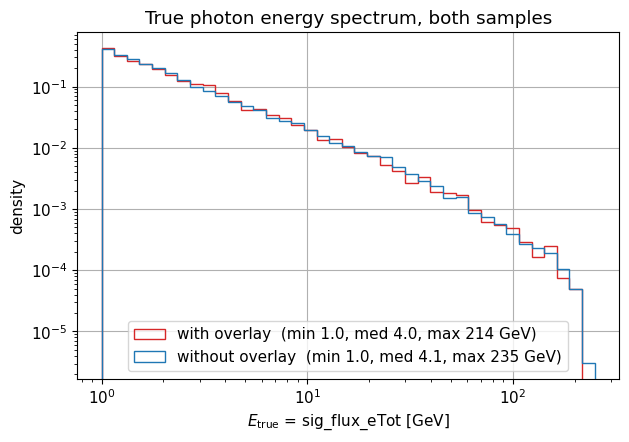

In [3]:
fig, ax = plt.subplots(figsize=(7, 4.5))
bins = np.geomspace(1, 250, 40)
for label, a, color in [("with overlay", wmb, "tab:red"),
                        ("without overlay", nmb, "tab:blue")]:
    et = ak.to_numpy(a["sig_flux_eTot"])
    ax.hist(et, bins=bins, histtype="step", density=True, color=color,
            label=f"{label}  (min {et.min():.1f}, med {np.median(et):.1f}, max {et.max():.0f} GeV)")
ax.set(xscale="log", yscale="log", xlabel=r"$E_{\rm true}$ = sig_flux_eTot [GeV]",
       ylabel="density", title="True photon energy spectrum, both samples")
ax.legend()
plt.show()

Same 1–235 GeV range and the same falling shape as the week-1 set, so `sig_flux_eTot` is in
GeV here too and the two photon populations are similar enough to compare.

## 2. The `_orig` branches are a per-cell record of what was removed

While diffing the schema I noticed each cell has *two* energies per layer:
`cell_energies_front` and `cell_energies_front_orig` (same for back). Checking the relation
cell by cell:

In [4]:
def removed_energy(a):
    # per-cell energy difference orig - current (front + back), jagged, >= 0
    e_now = a["cell_energies_front"] + a["cell_energies_back"]
    e_orig = a["cell_energies_front_orig"] + a["cell_energies_back_orig"]
    return e_orig - e_now, e_orig, e_now

for label, a in [("with overlay", wmb), ("without overlay", nmb)]:
    rem, e_orig, e_now = removed_energy(a)
    flat = ak.to_numpy(ak.flatten(rem))
    # sanity: the per-cell "energy" branch should match front+back of one of the two versions
    de = ak.to_numpy(ak.flatten(abs(a["energy"] - e_now)))
    print(f"{label}:")
    print(f"  cells where orig != current : {100 * np.mean(flat != 0):5.2f}%")
    print(f"  sign check                  : min(orig-current) = {flat.min():.3g}  (never negative -> energy only ever REMOVED)")
    print(f"  'energy' == front+back ?    : max |diff| = {de.max():.3g}")

with overlay:
  cells where orig != current : 15.31%
  sign check                  : min(orig-current) = 0  (never negative -> energy only ever REMOVED)
  'energy' == front+back ?    : max |diff| = 0
without overlay:
  cells where orig != current :  0.56%
  sign check                  : min(orig-current) = 0  (never negative -> energy only ever REMOVED)
  'energy' == front+back ?    : max |diff| = 0


So in both samples `energy = cell_energies_front + cell_energies_back` (the *current* values),
and the `_orig` branches hold a strictly-larger-or-equal original value. Energy was only ever
**removed** going from `_orig` to the current branches — and it was removed from ~15% of cells
in the overlay sample versus well under 1% without overlay.

My working hypothesis: `_orig` is the cell as the detector would record it (signal + overlay),
and the plain branches are the result of some cleaning/subtraction step in the matching code.
If that is right, this production contains a **per-cell ground truth for the noise** — for
every cell I know exactly how much energy did not belong to the photon. That is potentially a
supervision signal for a model, and definitely a mentor question (what step does the removal,
and which version would the real detector give us at inference time?).

A cell can then be one of three kinds:

- **clean** — has energy now, nothing was removed,
- **mixed** — has energy now, but some was removed,
- **pure noise** — has original energy but *zero* now (everything was removed).

                     clean     mixed  pure noise   (% of cells with any original energy)
with overlay          84.7      15.3       0.0
without overlay       99.4       0.6       0.0


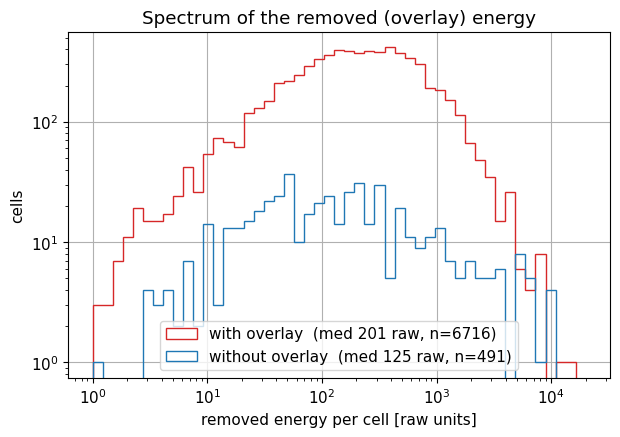

In [5]:
def cell_kinds(a):
    rem, e_orig, e_now = removed_energy(a)
    return {
        "clean":      (e_now > 0) & (rem == 0),
        "mixed":      (e_now > 0) & (rem > 0),
        "pure noise": (e_now == 0) & (e_orig > 0),
    }, rem, e_orig

print(f"{'':16s}{'clean':>10s}{'mixed':>10s}{'pure noise':>12s}   (% of cells with any original energy)")
for label, a in [("with overlay", wmb), ("without overlay", nmb)]:
    kinds, rem, e_orig = cell_kinds(a)
    n_any = float(ak.sum(e_orig > 0))
    row = "".join(f"{100 * float(ak.sum(m)) / n_any:>10.1f}" for m in kinds.values())
    print(f"{label:16s}{row}")
    if label == "with overlay":
        headline["cells touched by overlay"] = (
            f"{100 * float(ak.sum(kinds['mixed'] | kinds['pure noise'])) / n_any:.0f}% "
            f"(vs <1% without)")

# how much energy per affected cell?
fig, ax = plt.subplots(figsize=(7, 4.5))
bins = np.geomspace(1, 2e4, 50)
for label, a, color in [("with overlay", wmb, "tab:red"),
                        ("without overlay", nmb, "tab:blue")]:
    rem = removed_energy(a)[0]
    vals = ak.to_numpy(ak.flatten(rem[rem > 0]))
    ax.hist(vals, bins=bins, histtype="step", color=color,
            label=f"{label}  (med {np.median(vals):.0f} raw, n={len(vals)})")
ax.set(xscale="log", yscale="log", xlabel="removed energy per cell [raw units]",
       ylabel="cells", title="Spectrum of the removed (overlay) energy")
ax.legend()
plt.show()

### 2b. Where does the overlay hit?

The **pure-noise class came out empty**: cells whose energy was removed entirely are not
stored at all. That is consistent with what section 3 finds about this format — only the
cluster-member cells are written out. So the per-cell noise record covers the *partially*
affected (mixed) cells; overlay-only cells are silently gone from the arrays.

Minimum-bias particles are densest near the beam pipe, so the fraction of affected cells
should fall with radius. The cluster windows only sample certain radii, but the trend should
still show.

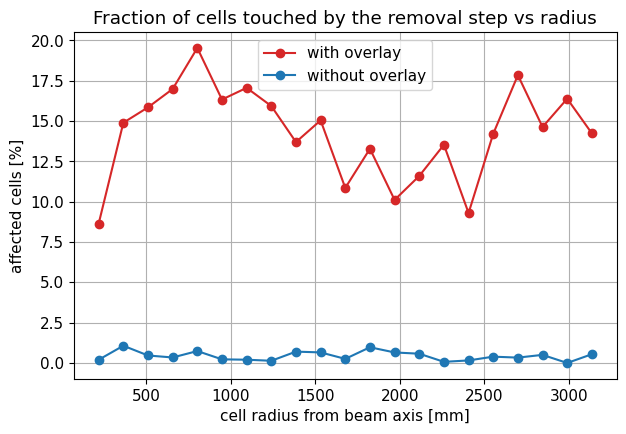

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
rbins = np.linspace(0, 3500, 25)
for label, a, color in [("with overlay", wmb, "tab:red"),
                        ("without overlay", nmb, "tab:blue")]:
    kinds, rem, e_orig = cell_kinds(a)
    affected = kinds["mixed"] | kinds["pure noise"]
    sel = e_orig > 0
    r = ak.to_numpy(ak.flatten(np.hypot(a["cell_x"], a["cell_y"])[sel]))
    aff = ak.to_numpy(ak.flatten(affected[sel]))
    centers, frac = [], []
    for lo, hi in zip(rbins[:-1], rbins[1:]):
        m = (r >= lo) & (r < hi)
        if m.sum() >= 200:
            centers.append(0.5 * (lo + hi))
            frac.append(aff[m].mean())
    ax.plot(centers, 100 * np.asarray(frac), "o-", color=color, label=label)
ax.set(xlabel="cell radius from beam axis [mm]", ylabel="affected cells [%]",
       title="Fraction of cells touched by the removal step vs radius")
ax.legend()
plt.show()

### 2c. One cluster, before and after

A picture of what the overlay does to a single cluster: original cell energies (left), the
cleaned version the branches give me (middle), and the removed part (right).

cluster 2312: E_true = 59.5 GeV, 7 affected cells


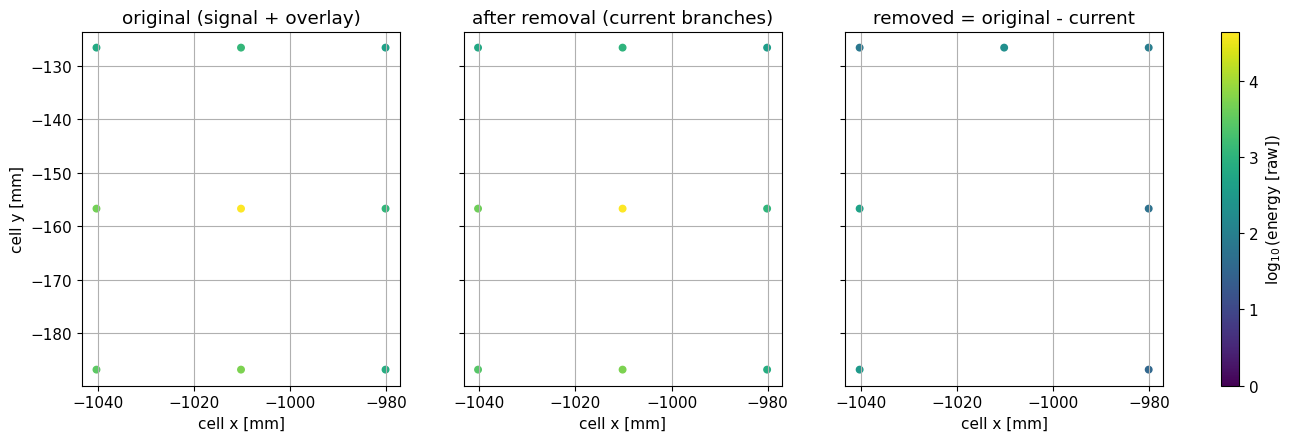

In [7]:
kinds_w, rem_w, e_orig_w = cell_kinds(wmb)
n_aff = ak.to_numpy(ak.sum(kinds_w["mixed"] | kinds_w["pure noise"], axis=1))
et_w = ak.to_numpy(wmb["sig_flux_eTot"])
cand = np.where((et_w > 20) & (et_w < 60))[0]
idx = int(cand[np.argmax(n_aff[cand])])
print(f"cluster {idx}: E_true = {et_w[idx]:.1f} GeV, {n_aff[idx]} affected cells")

x = ak.to_numpy(wmb["cell_x"][idx]); y = ak.to_numpy(wmb["cell_y"][idx])
e_orig = ak.to_numpy(e_orig_w[idx]); e_now = ak.to_numpy(wmb["energy"][idx])
rem = ak.to_numpy(rem_w[idx])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharex=True, sharey=True)
vmax = np.log10(e_orig.max())
for ax, vals, title in [(axes[0], e_orig, "original (signal + overlay)"),
                        (axes[1], e_now, "after removal (current branches)"),
                        (axes[2], rem, "removed = original - current")]:
    sel = vals > 0
    sc = ax.scatter(x[sel], y[sel], c=np.log10(vals[sel]), s=22,
                    cmap="viridis", vmin=0, vmax=vmax)
    ax.set(title=title, xlabel="cell x [mm]")
axes[0].set_ylabel("cell y [mm]")
fig.colorbar(sc, ax=axes, label=r"$\log_{10}$(energy [raw])", fraction=0.02)
plt.show()

## 3. Cluster anatomy with vs without overlay

How different does the *input* to a model look? Informative-cell counts and the per-cell
energy spectrum, side by side.

One structural surprise first: this production does **not** store the full 5×5-module window.
The week-1 files keep every window cell (~140 per cluster, about half of them silent); here the
arrays are an order of magnitude shorter and essentially every stored cell has energy — only
the cluster-member cells were written out. So the tokenization that notebook 01 worked out
("drop the silent cells") is already done upstream in this production.

with overlay       silent-cell fraction = 0.000
without overlay    silent-cell fraction = 0.003


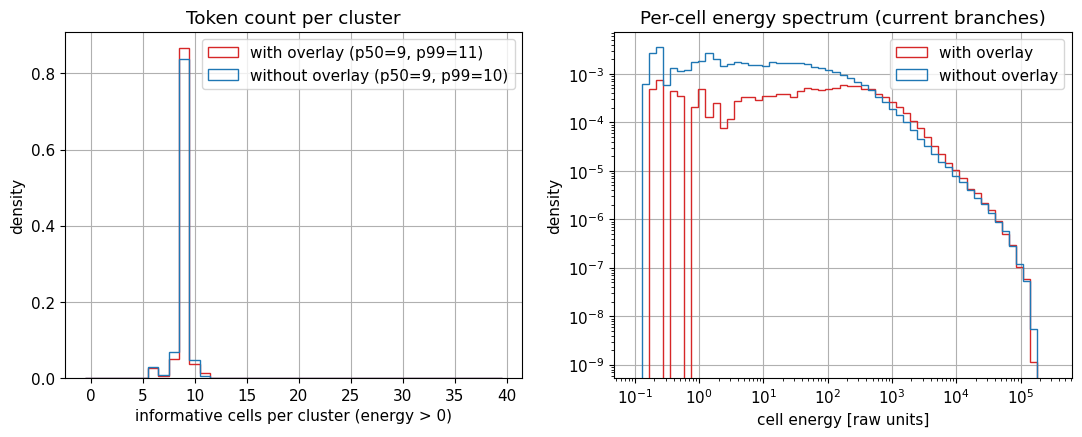

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for label, a, color in [("with overlay", wmb, "tab:red"),
                        ("without overlay", nmb, "tab:blue")]:
    nz = ak.to_numpy(ak.sum(a["energy"] > 0, axis=1))
    ntot = ak.to_numpy(ak.num(a["energy"], axis=1))
    axes[0].hist(nz, bins=np.arange(-0.5, 40.5, 1), histtype="step", density=True,
                 color=color, label=f"{label} (p50={int(np.median(nz))}, p99={int(np.percentile(nz, 99))})")
    e = ak.to_numpy(ak.flatten(a["energy"]))
    e = e[e > 0]
    axes[1].hist(e, bins=np.geomspace(0.1, 3e5, 60), histtype="step", density=True,
                 color=color, label=label)
    print(f"{label:18s} silent-cell fraction = {1 - nz.sum() / ntot.sum():.3f}")
axes[0].set(xlabel="informative cells per cluster (energy > 0)", ylabel="density",
            title="Token count per cluster")
axes[1].set(xscale="log", yscale="log", xlabel="cell energy [raw units]", ylabel="density",
            title="Per-cell energy spectrum (current branches)")
for ax in axes:
    ax.legend()
plt.show()

## 4. Response: how much extra energy does the overlay leave in the sum?

Same recipe as notebook 01 section 8: single calibration constant per sample fitted on even
events (E_true > 4 GeV, dr < 100 mm), bias evaluated on odd events. The two samples get
**separate** constants — the gain is not the same across productions, so re-using week 1's
967 raw/GeV would be wrong here.

with overlay       gain =   2029 raw/GeV, median bias @ lowest bin = +1072%
without overlay    gain =   1893 raw/GeV, median bias @ lowest bin = +983%


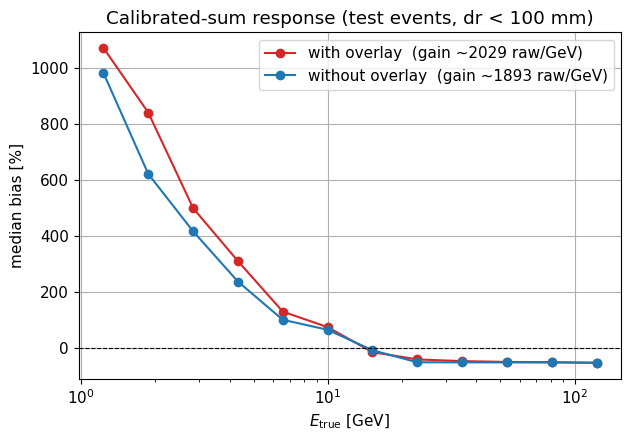

In [9]:
def response_setup(a):
    et = ak.to_numpy(a["sig_flux_eTot"])
    dr = ak.to_numpy(a["sig_dr_matched"])
    ev = ak.to_numpy(a["event"])
    tot = ak.to_numpy(ak.sum(a["energy"], axis=1))
    sel = (dr < 100) & (tot > 0)
    train = sel & (ev % 2 == 0)
    test = sel & (ev % 2 == 1)
    k = np.median(et[train & (et > 4)] / tot[train & (et > 4)])
    resp = np.where(tot > 0, (k * tot - et) / et, np.nan)
    return et, resp, test, 1.0 / k

ebins = np.geomspace(1, 230, 14)

def binned(e, v, stat, min_n=40):
    cs, vs, ns = [], [], []
    for lo, hi in zip(ebins[:-1], ebins[1:]):
        m = (e >= lo) & (e < hi) & np.isfinite(v)
        if m.sum() >= min_n:
            cs.append(np.sqrt(lo * hi)); vs.append(stat(v[m])); ns.append(m.sum())
    return np.array(cs), np.array(vs), np.array(ns)

fig, ax = plt.subplots(figsize=(7, 4.5))
curves = {}
for label, a, color in [("with overlay", wmb, "tab:red"),
                        ("without overlay", nmb, "tab:blue")]:
    et, resp, test, gain = response_setup(a)
    curves[label] = (et, resp, test)
    c, b, n = binned(et[test], resp[test], np.median)
    ax.plot(c, 100 * b, "o-", color=color, label=f"{label}  (gain ~{gain:.0f} raw/GeV)")
    print(f"{label:18s} gain = {gain:6.0f} raw/GeV, median bias @ lowest bin = {100 * b[0]:+.0f}%")
    headline[f"gain {label}"] = f"{gain:.0f} raw/GeV"
ax.axhline(0, color="k", ls="--", lw=0.8)
ax.set(xscale="log", xlabel=r"$E_{\rm true}$ [GeV]", ylabel="median bias [%]",
       title="Calibrated-sum response (test events, dr < 100 mm)")
ax.legend()
plt.show()

## 5. Resolution: the cost of the overlay

Robust σ (half-width of the central 68%) of the relative residual per energy bin, with
bootstrap error bars. With ~5k and ~10k clusters the bins are thin, so I plot the binned
points only and skip the $a/\sqrt{E} \oplus b$ fit — the *gap between the two curves* is the
quantity of interest, not the absolute numbers.

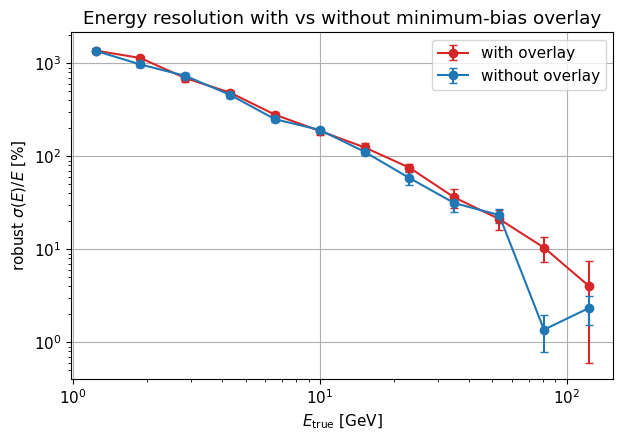

In [10]:
def robust_sigma(x):
    q16, q84 = np.percentile(x, [15.865, 84.135])
    return 0.5 * (q84 - q16)

def boot_err(x, stat, n=200):
    return np.std([stat(rng.choice(x, len(x))) for _ in range(n)])

fig, ax = plt.subplots(figsize=(7, 4.5))
for label, color in [("with overlay", "tab:red"), ("without overlay", "tab:blue")]:
    et, resp, test = curves[label]
    e, v = et[test], resp[test]
    cs, ss, errs = [], [], []
    for lo, hi in zip(ebins[:-1], ebins[1:]):
        m = (e >= lo) & (e < hi) & np.isfinite(v)
        if m.sum() >= 40:
            cs.append(np.sqrt(lo * hi))
            ss.append(robust_sigma(v[m]))
            errs.append(boot_err(v[m], robust_sigma))
    cs, ss, errs = map(np.array, (cs, ss, errs))
    ax.errorbar(cs, 100 * ss, yerr=100 * errs, fmt="o-", color=color, label=label, capsize=3)
    hi_bin = cs > 50
    if hi_bin.any():
        headline[f"sigma/E above 50 GeV, {label}"] = f"{100 * ss[hi_bin].mean():.1f}%"
ax.set(xscale="log", yscale="log", xlabel=r"$E_{\rm true}$ [GeV]",
       ylabel=r"robust $\sigma(E)/E$ [%]",
       title="Energy resolution with vs without minimum-bias overlay")
ax.legend()
plt.show()

## 6. Can timing tag the noise?

This is the question the whole proposal hangs on. Section 2 gives me labelled cells — clean
and mixed (the pure-noise class is not stored, see 2b) — so I can at least ask: do the cells
that received overlay energy show a different time than the untouched ones?

The honest answer on this sample: **no**. The mixed cells' median arrival time matches the
clean cells' to 0.01 ns. My reading is that the stored time describes the *cleaned* deposit —
the photon's own energy in that cell — so whatever out-of-time character the overlay had was
removed together with its energy. Combined with 2b (overlay-only cells are dropped entirely),
this sample cannot show an out-of-time noise signature even if one exists. For the real
detector, where every cell above threshold gets a SPIDER timestamp regardless of ownership,
the question stays open — it goes on the mentor list instead of being settled here.

(I validate times against the **original** energy rather than the loader's `energy > 0` rule,
keeping the |t| < 10⁴ ns sanity cut, so any removed-but-stored cell would have had its chance.)

clean       median dt =   43.17 ns, robust sigma =   0.38 ns, 99% inside plot range, n = 26991 valid of 37126 cells
mixed       median dt =   43.16 ns, robust sigma =   0.15 ns, 98% inside plot range, n = 4220 valid of 6716 cells
pure noise  no cells of this kind in the stored arrays (0 cells)


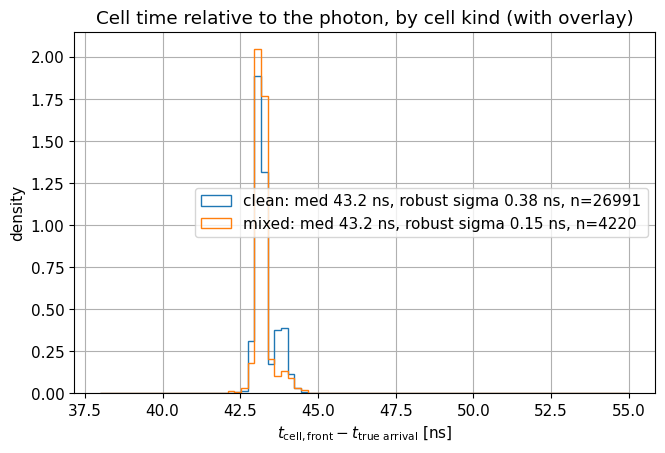

In [11]:
kinds, rem, e_orig = cell_kinds(wmb)
mask_orig = e_orig > 0
t = clean_cell_times(wmb["cell_times_front"], mask_orig)
dt = t - wmb["sig_flux_timing"]   # cell time minus true photon arrival, per cell [ns]

fig, ax = plt.subplots(figsize=(7.5, 4.7))
bins = np.linspace(38, 55, 80)
for kind, color in [("clean", "tab:blue"), ("mixed", "tab:orange"), ("pure noise", "tab:red")]:
    n_cells = int(ak.sum(kinds[kind]))
    vals = ak.to_numpy(ak.flatten(dt[kinds[kind]]))
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        print(f"{kind:11s} no cells of this kind in the stored arrays ({n_cells} cells)")
        continue
    med, sig = np.median(vals), robust_sigma(vals)
    frac_in = np.mean((vals > bins[0]) & (vals < bins[-1]))
    ax.hist(vals, bins=bins, histtype="step", density=True, color=color,
            label=f"{kind}: med {med:.1f} ns, robust sigma {sig:.2f} ns, n={len(vals)}")
    print(f"{kind:11s} median dt = {med:7.2f} ns, robust sigma = {sig:6.2f} ns, "
          f"{100 * frac_in:.0f}% inside plot range, n = {len(vals)} valid of {n_cells} cells")
ax.set(xlabel=r"$t_{\rm cell,front} - t_{\rm true\ arrival}$ [ns]", ylabel="density",
       title="Cell time relative to the photon, by cell kind (with overlay)")
ax.legend()
plt.show()

## 7. Summary

(numbers collected during the run)

In [12]:
for k, v in headline.items():
    print(f"{k:40s} {v}")

clusters with / without                  4913 / 9861
cells touched by overlay                 15% (vs <1% without)
gain with overlay                        2029 raw/GeV
gain without overlay                     1893 raw/GeV
sigma/E above 50 GeV, with overlay       11.9%
sigma/E above 50 GeV, without overlay    9.0%


### What I take away

1. **"Noise" = minimum bias = real particles from the other collisions in the same bunch
   crossing** (mostly soft hadrons and π⁰ photons), not electronics noise. The notebook's
   numbers above quantify what it does to a cluster.
2. This production carries a **per-cell record of the overlay**: `_orig` minus current cell
   energies. Roughly one cell in six is touched with overlay on; almost none without. If the
   plain branches really are "after subtraction", the realistic model input is the `_orig`
   version — and the difference is free per-cell supervision. Needs mentor confirmation.
3. The overlay is **position-structured** (worse toward the beam pipe) — consistent with the
   physics expectation, and a feature a model can use.
4. This production stores **only the cluster-member cells** (~9 per cluster, almost no silent
   cells) instead of week-1's full 5×5 window (~140 cells, half silent). The "drop silent
   cells" tokenization from notebook 01 is already applied upstream here.
5. **Timing cannot tag the noise on this sample** — overlay-only cells are dropped from the
   arrays entirely, and the cells that kept part of their energy show times identical to
   untouched cells (median Δt 43.16 vs 43.17 ns), presumably because the stored time describes
   the cleaned deposit. On the real detector every cell above threshold is timestamped, so the
   question goes to the mentors instead of being settled here.
6. Each production needs its **own calibration constant**; week-1's gain does not carry over.
7. Resolution and response comparisons across the two samples come with the caveat that the
   productions differ in more than the overlay (different file ranges and dates).

### Questions for the mentors

1. What step produces `cell_energies_*` from `cell_energies_*_orig` — is it a minimum-bias /
   out-of-time subtraction inside the matching code? Which version corresponds to what the
   detector would hand us at inference time?
2. How many minimum-bias interactions per crossing were overlaid here, and is electronics
   noise simulated at all?
3. Are the two Drive samples otherwise identical (geometry, smearing, generator settings), so
   differences can be attributed to the overlay alone?
4. The newer 100-file production has neither `_orig` nor `*_corr` branches. Will the
   minbias production we eventually train on include them? Per-cell noise labels would let us
   supervise a denoising / attention model directly.
5. The raw gain differs per production (here ~2030 and ~1890 raw/GeV vs ~970 in week 1) — is
   that expected (different calibration in the simulation), or a sign I am misreading a unit?
6. Cells fully removed by the cleaning are not stored, and the stored times appear to describe
   the cleaned deposit. Will the minbias production we train on keep the noise cells *with*
   their raw times? Out-of-time rejection is exactly what we hope a space-time model can
   learn, so without those cells and times the central ablation cannot be run.

### What this changes for the plan

Nothing in week 1 has to be redone — the no-overlay conclusions stand. But the Stage-2
("with background") work should assume: per-sample calibration, the `_orig` branches as the
honest input if the mentors confirm the hypothesis, and timing + position as the two handles
the model gets for separating overlay from signal.